In [1]:
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler


In [2]:

# Tạo dữ liệu phức tạp hơn với nhiễu
X, _ = make_blobs(n_samples=500, centers=5, n_features=2,
 cluster_std=1.5, random_state=42)


In [3]:

# Thêm nhiễu
noise = np.random.normal(0, 2, X.shape)
X_noisy = X + noise * 0.5


In [4]:

# Chuẩn hóa
X_scaled = StandardScaler().fit_transform(X_noisy)


In [5]:

# So sánh Elbow và Silhouette
k_range = range(2, 11)
wcss_list = []
silhouette_list = []

for k in k_range:
 kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
 labels = kmeans.fit_predict(X_scaled)
 wcss_list.append(kmeans.inertia_)
 silhouette_list.append(silhouette_score(X_scaled, labels))
 

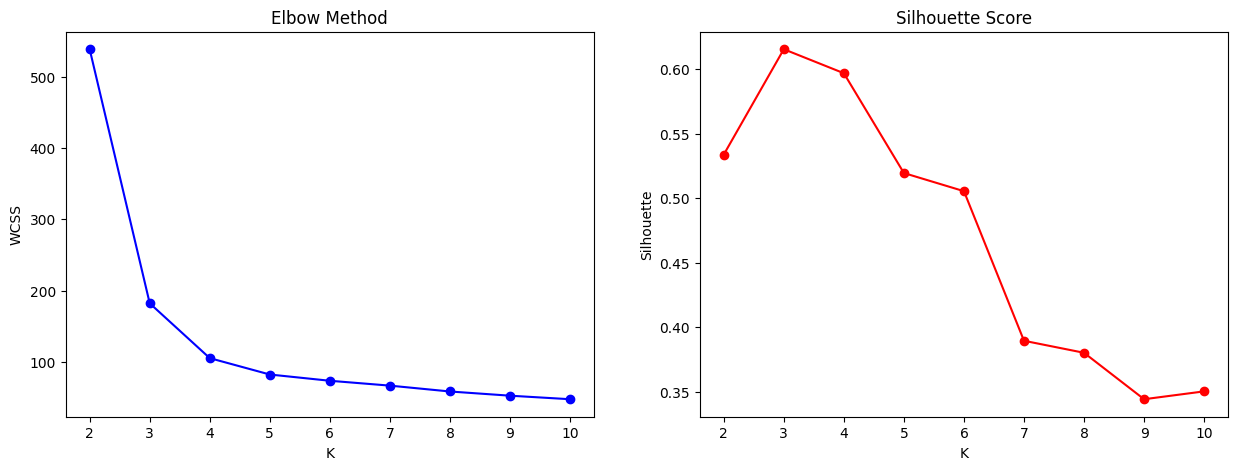

In [6]:

 # Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(k_range, wcss_list, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('WCSS')
axes[1].plot(k_range, silhouette_list, 'ro-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette')
plt.show()


In [7]:

# Chọn K và vẽ Silhouette Plot chi tiết
optimal_k = 4 # Dựa trên cả 2 phương pháp
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X_scaled)